In [16]:
# Install dependencies (run once):
#   pip install numpy matplotlib Pillow tensorflow
import os
import glob

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from tensorflow import keras
from keras import layers

✅ Images Loaded: Found 200 'high' images and 200 'low' images.


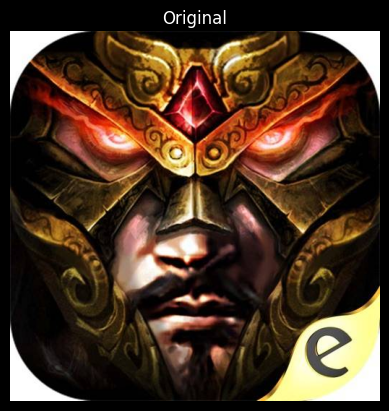

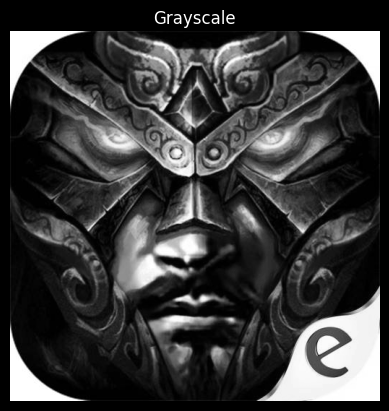

In [18]:
# --- Load images ---

high_dir = "/Users/alinakatiliute/university/BIM RSM/Deep Learning Python/Data/high/"
low_dir = "/Users/alinakatiliute/university/BIM RSM/Deep Learning Python/Data/low/"

def load_images(directory):
    paths = sorted(glob.glob(os.path.join(directory, "*.jpg")))
    return [np.array(Image.open(p).convert("RGB")) for p in paths]


pics_high = load_images(high_dir)
pics_low = load_images(low_dir)

print(f"✅ Images Loaded: Found {len(pics_high)} 'high' images and {len(pics_low)} 'low' images.")

# Example: convert one image to grayscale and display it.
image = Image.open(sorted(glob.glob(os.path.join(low_dir, "*.jpg")))[1])
plt.imshow(image)
plt.title("Original")
plt.axis("off")
plt.show()

z_gray = image.convert("L")
plt.imshow(z_gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")
plt.show()

✅ Data Split Complete!
   -> Training Set Shape: (319, 128, 128, 3)
   -> Testing Set Shape:  (81, 128, 128, 3)


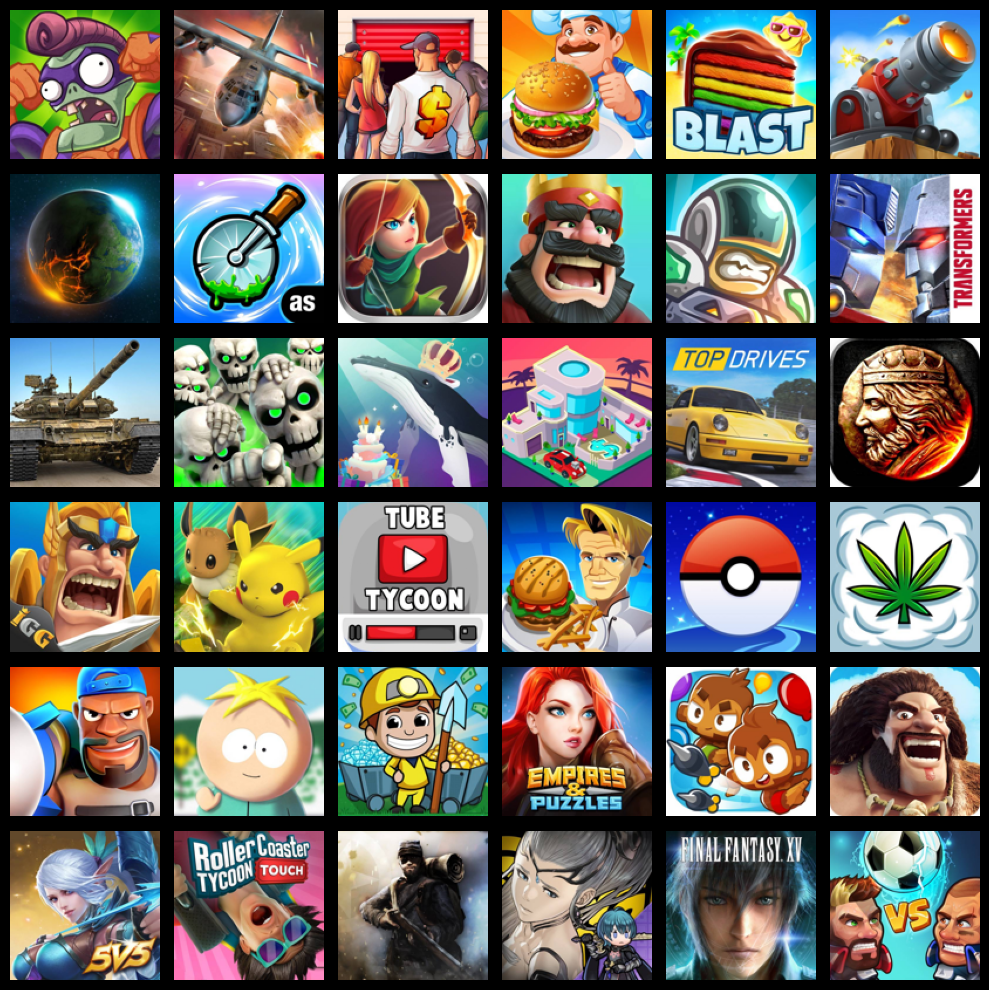

In [13]:
# --- Labels ---

objective = np.array([1] * 200 + [0] * 200)  # 1 = high, 0 = low.

# --- Merge and resize ---

all_images = pics_high + pics_low  # List of 400 numpy arrays.

TARGET_SIZE = (128, 128)


def resize_image(img_array):
    img = Image.fromarray(img_array).resize(TARGET_SIZE)
    return np.array(img)


picts = [resize_image(img) for img in all_images]

# --- Train / test split (80 / 20) ---

np.random.seed(42)
tf.random.set_seed(42)
indexes = np.random.choice([1, 2], size=len(picts), replace=True, p=[0.8, 0.2])

train_images = [picts[i] for i in range(len(picts)) if indexes[i] == 1]
test_images = [picts[i] for i in range(len(picts)) if indexes[i] == 2]
tr_obj = objective[indexes == 1]
te_obj = objective[indexes == 2]

# --- Stack into arrays and normalize ---

# Shape: (N, 128, 128, 3), pixels scaled to [0, 1].
train_corpus = np.stack(train_images).astype("float32") / 255.0
test_corpus = np.stack(test_images).astype("float32") / 255.0

print(f"✅ Data Split Complete!")
print(f"   -> Training Set Shape: {train_corpus.shape}")
print(f"   -> Testing Set Shape:  {test_corpus.shape}")

# --- Plot a 6x6 grid of training images ---

fig, axes = plt.subplots(6, 6, figsize=(10, 10))
for idx, ax in enumerate(axes.flat):
    ax.imshow(train_corpus[idx])
    ax.axis("off")
plt.tight_layout()
plt.show()

# --- One-hot encode labels ---

train_target = keras.utils.to_categorical(tr_obj, num_classes=2)
test_target = keras.utils.to_categorical(te_obj, num_classes=2)

In [15]:
# --- Build CNN ---

model = keras.Sequential([
    layers.Conv2D(32, (2, 2), activation="relu", input_shape=(128, 128, 3)),
    layers.Conv2D(32, (2, 2), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.25),
    layers.Dense(2, activation="softmax"),
])

model.summary()

# --- Compile ---

model.compile(
    loss="categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"],
)

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_9 (Conv2D)           (None, 127, 127, 32)      416       
                                                                 
 conv2d_10 (Conv2D)          (None, 126, 126, 32)      4128      
                                                                 
 max_pooling2d_6 (MaxPoolin  (None, 63, 63, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_11 (Conv2D)          (None, 61, 61, 32)        9248      
                                                                 
 max_pooling2d_7 (MaxPoolin  (None, 30, 30, 32)        0         
 g2D)                                                            
                                                                 
 flatten_3 (Flatten)         (None, 28800)            

Epoch 1/20
4/4 [==============================] - 5s 1s/step - loss: 1.9581 - accuracy: 0.5490 - val_loss: 0.2648 - val_accuracy: 1.0000
Epoch 2/20
4/4 [==============================] - 4s 1s/step - loss: 0.8363 - accuracy: 0.3922 - val_loss: 0.7167 - val_accuracy: 0.0156
Epoch 3/20
4/4 [==============================] - 3s 788ms/step - loss: 0.6714 - accuracy: 0.6471 - val_loss: 0.9104 - val_accuracy: 0.0000e+00
Epoch 4/20
4/4 [==============================] - 7s 2s/step - loss: 0.6627 - accuracy: 0.6196 - val_loss: 0.9361 - val_accuracy: 0.0000e+00
Epoch 5/20
4/4 [==============================] - 4s 994ms/step - loss: 0.6453 - accuracy: 0.6196 - val_loss: 0.9901 - val_accuracy: 0.0000e+00
Epoch 6/20
4/4 [==============================] - 3s 636ms/step - loss: 0.6248 - accuracy: 0.6235 - val_loss: 0.8475 - val_accuracy: 0.0000e+00
Epoch 7/20
4/4 [==============================] - 2s 663ms/step - loss: 0.6011 - accuracy: 0.7373 - val_loss: 1.1494 - val_accuracy: 0.0000e+00
Epoch 8/2

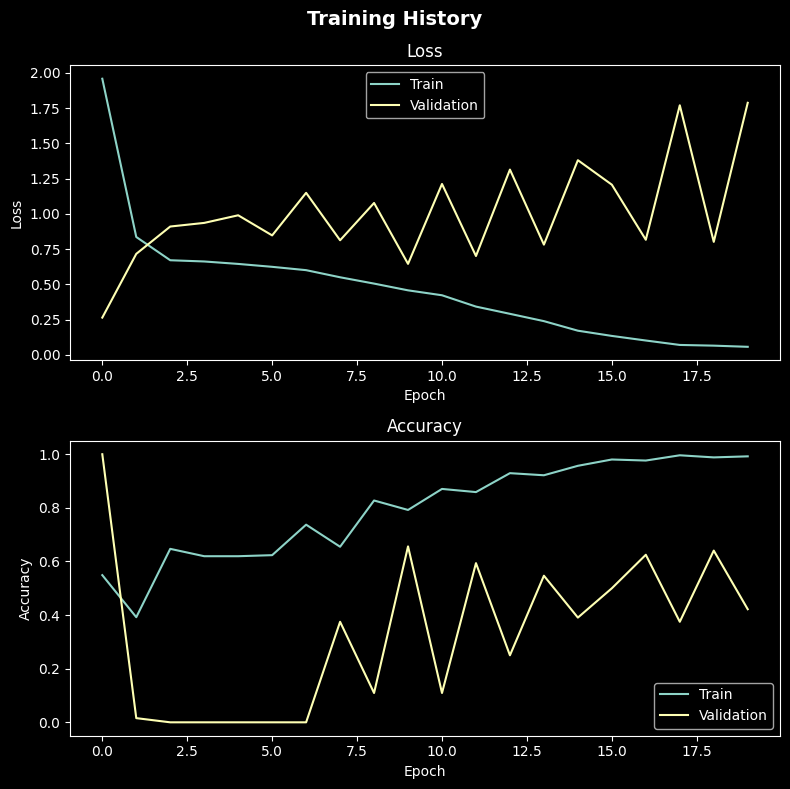

In [10]:
# --- Train ---

history = model.fit(
    train_corpus, train_target,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
)

# --- Plot training history ---

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8))

ax1.plot(history.history["loss"], label="Train")
ax1.plot(history.history["val_loss"], label="Validation")
ax1.set_title("Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()

ax2.plot(history.history["accuracy"], label="Train")
ax2.plot(history.history["val_accuracy"], label="Validation")
ax2.set_title("Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.legend()

plt.suptitle("Training History", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [11]:
# --- Evaluate and predict - train data ---

train_loss, train_acc = model.evaluate(train_corpus, train_target, verbose=0)
pred_train = model.predict(train_corpus)

# --- Evaluate and predict - test data ---

test_loss, test_acc = model.evaluate(test_corpus, test_target, verbose=0)
pred_test = model.predict(test_corpus)

# --- Print results ---

print(f"\nTrain - loss: {train_loss:.4f}  accuracy: {train_acc:.2%}")
print(f"Test  - loss: {test_loss:.4f}  accuracy: {test_acc:.2%}")

3/3 [==============================] - 0s 45ms/step

Train - loss: 0.3834  accuracy: 88.40%
Test  - loss: 1.2204  accuracy: 64.20%


----------------------------










### Updated model to decrease overfitting:

In [20]:
# ==========================================
# CELL 4: BUILD AND TRAIN (WITH AUGMENTATION)
# ==========================================
# 1. We create an augmentation pipeline
data_augmentation = keras.Sequential([
  layers.RandomFlip("horizontal", input_shape=(128, 128, 3)),
  layers.RandomRotation(0.1),
  layers.RandomZoom(0.1),
])

# 2. Build the Model
model = keras.Sequential([
    # Step A: Augment the tiny dataset
    data_augmentation,

    # Step B: The CNN Scanning Senses
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    # Step C: A smaller, heavily restricted brain
    layers.Dense(64, activation="relu"), # Shrunk from 256 to 64
    layers.Dropout(0.6), # Massive 60% dropout to force generalization
    layers.Dense(2, activation="softmax"),
])

model.summary()

# 3. Compile
model.compile(
    loss="categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"],
)

print("\n✅ Cell 4 Complete: Neural Network successfully built with Augmentation!")

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential_4 (Sequential)   (None, 128, 128, 3)       0         
                                                                 
 conv2d_12 (Conv2D)          (None, 126, 126, 32)      896       
                                                                 
 max_pooling2d_8 (MaxPoolin  (None, 63, 63, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_13 (Conv2D)          (None, 61, 61, 32)        9248      
                                                                 
 max_pooling2d_9 (MaxPoolin  (None, 30, 30, 32)        0         
 g2D)                                                            
                                                                 
 flatten_4 (Flatten)         (None, 28800)            

🔀 Shuffling the training data...
🚀 Beginning Training...
Epoch 1/20
4/4 [==============================] - 4s 622ms/step - loss: 1.1271 - accuracy: 0.5137 - val_loss: 0.6943 - val_accuracy: 0.4219
Epoch 2/20
4/4 [==============================] - 2s 469ms/step - loss: 0.7600 - accuracy: 0.5255 - val_loss: 0.7103 - val_accuracy: 0.4688
Epoch 3/20
4/4 [==============================] - 2s 547ms/step - loss: 0.7019 - accuracy: 0.4863 - val_loss: 0.6944 - val_accuracy: 0.4844
Epoch 4/20
4/4 [==============================] - 3s 772ms/step - loss: 0.6889 - accuracy: 0.5216 - val_loss: 0.6938 - val_accuracy: 0.5156
Epoch 5/20
4/4 [==============================] - 3s 642ms/step - loss: 0.6917 - accuracy: 0.4980 - val_loss: 0.6948 - val_accuracy: 0.4062
Epoch 6/20
4/4 [==============================] - 3s 706ms/step - loss: 0.6882 - accuracy: 0.5451 - val_loss: 0.6950 - val_accuracy: 0.4062
Epoch 7/20
4/4 [==============================] - 6s 1s/step - loss: 0.6824 - accuracy: 0.5255 - val_lo

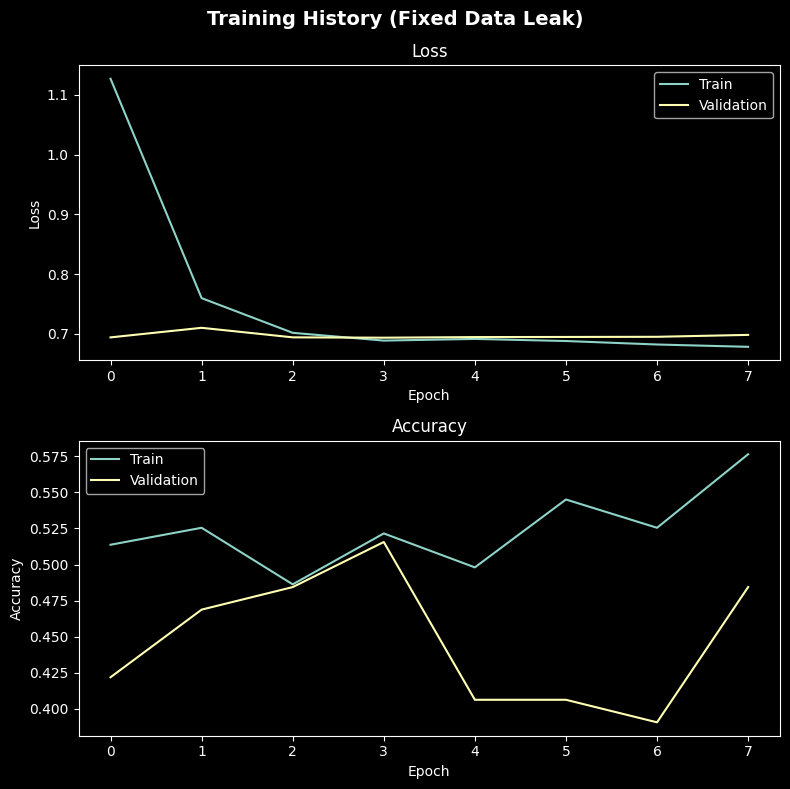

In [21]:
# ==========================================
# CELL 5: SHUFFLE AND TRAIN
# ==========================================
from keras.callbacks import EarlyStopping

print("🔀 Shuffling the training data...")

# 1. THE FIX: Manually shuffle the arrays so the 1s and 0s are mixed!
indices = np.arange(train_corpus.shape[0])
np.random.shuffle(indices)
train_corpus_shuffled = train_corpus[indices]
train_target_shuffled = train_target[indices]

# 2. Add Early Stopping to prevent normal overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)

print("🚀 Beginning Training...")

# 3. Train using the SHUFFLED data
history = model.fit(
    train_corpus_shuffled, train_target_shuffled,
    epochs=20,
    batch_size=64,
    validation_split=0.2, # Now this will take a healthy mix of 1s and 0s!
    callbacks=[early_stop]
)

print("✅ Training Complete! Generating performance graphs...")

# --- Plot training history ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8))

ax1.plot(history.history["loss"], label="Train")
ax1.plot(history.history["val_loss"], label="Validation")
ax1.set_title("Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()

ax2.plot(history.history["accuracy"], label="Train")
ax2.plot(history.history["val_accuracy"], label="Validation")
ax2.set_title("Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.legend()

plt.suptitle("Training History (Fixed Data Leak)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()